In [1]:
import os

# Download EuroSAT from torchvision directly — most reliable method
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# This downloads and sets up EuroSAT automatically
dataset = datasets.EuroSAT(
    root="./data",
    transform=transforms.ToTensor(),
    download=True
)

print(f"Total images: {len(dataset)}")
print(f"Classes: {dataset.classes}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 250MB/s]


Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Image shape: torch.Size([3, 64, 64])
Image dtype: torch.float32
Pixel range: 0.32 to 0.80
Label: 0 = AnnualCrop


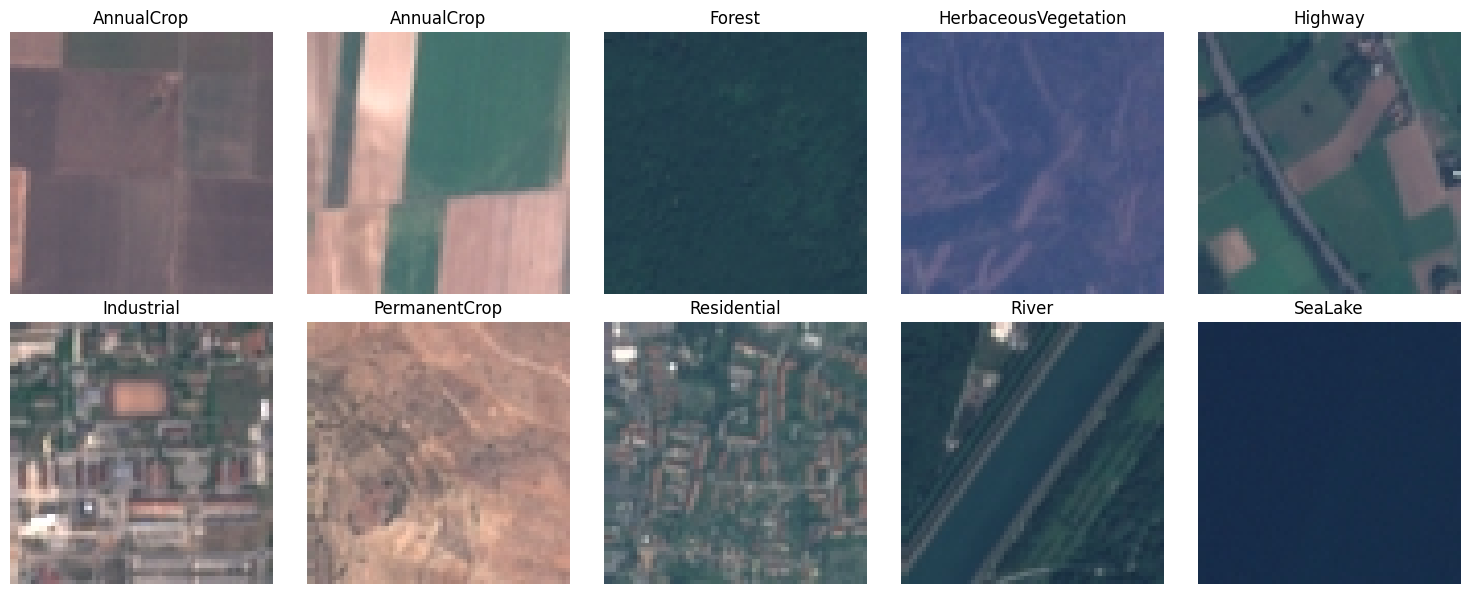

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Look at one sample
image, label = dataset[0]
print(f"Image shape: {image.shape}")       # (C, H, W)
print(f"Image dtype: {image.dtype}")
print(f"Pixel range: {image.min():.2f} to {image.max():.2f}")
print(f"Label: {label} = {dataset.classes[label]}")

# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img, lbl = dataset[i * 2700]    # one from each class
    img = img.permute(1, 2, 0)      # (C,H,W) → (H,W,C) for matplotlib
    ax.imshow(img)
    ax.set_title(dataset.classes[lbl])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [3]:
from torch.utils.data import DataLoader, random_split

# Split dataset — 80% train, 20% validation
train_size = int(0.8 * len(dataset))   # 21,600
val_size = len(dataset) - train_size   # 5,400

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

# DataLoader — batches + shuffles data automatically
train_loader = DataLoader(
    train_dataset,
    batch_size=32,        # 32 images per step
    shuffle=True,         # shuffle every epoch
    num_workers=2         # parallel data loading
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,        # never shuffle validation
    num_workers=2
)

# Inspect one batch
images, labels = next(iter(train_loader))
print(f"\nBatch image shape: {images.shape}")   # (32, 3, 64, 64)
print(f"Batch label shape: {labels.shape}")     # (32,)
print(f"Labels in batch:   {labels}")


Train samples: 21600
Val samples:   5400

Batch image shape: torch.Size([32, 3, 64, 64])
Batch label shape: torch.Size([32])
Labels in batch:   tensor([3, 2, 5, 4, 3, 4, 8, 2, 4, 6, 9, 4, 4, 5, 7, 2, 0, 2, 9, 6, 1, 3, 1, 0,
        0, 2, 8, 3, 6, 1, 3, 7])


In [4]:
import torchvision.transforms as transforms

# EuroSAT mean and std (precomputed for this dataset)
mean = [0.3444, 0.3803, 0.4078]
std  = [0.2038, 0.1367, 0.1147]

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)   # zero-center each channel
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)   # same normalization, no augmentation
])

# Reload dataset with transforms
train_dataset = datasets.EuroSAT(root="./data", transform=train_transforms, download=False)
val_dataset   = datasets.EuroSAT(root="./data", transform=val_transforms,   download=False)

# Split again
train_dataset, val_dataset = random_split(train_dataset, [21600, 5400])

# Reload dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

# Verify
images, labels = next(iter(train_loader))
print(f"Pixel mean after normalize: {images.mean():.4f}")   # close to 0
print(f"Pixel std after normalize:  {images.std():.4f}")    # close to 1

Pixel mean after normalize: 0.0546
Pixel std after normalize:  1.0529


In [5]:
# Confirm everything is still in memory
print(len(train_loader.dataset))
print(len(val_loader.dataset))

21600
5400


In [6]:
import torchvision.models as models
import torch.nn as nn

# Load ResNet18 pretrained on ImageNet
model = models.resnet18(weights='IMAGENET1K_V1')

# See the full architecture
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
# Replace final layer — 512 in, 10 out (our 10 classes)
model.fc = nn.Linear(512, 10)

# Freeze all layers except the final layer
for name, param in model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

# Verify — only fc parameters should be trainable
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Frozen parameters:    {total - trainable:,}")

# Move model to GPU
model = model.to('cuda')
print(f"\nModel on: {next(model.parameters()).device}")

Total parameters:     11,181,642
Trainable parameters: 5,130
Frozen parameters:    11,176,512

Model on: cuda:0


In [8]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Quick sanity check before full training
# Pass one batch through — confirm no shape errors
images, labels = next(iter(train_loader))
images, labels = images.to('cuda'), labels.to('cuda')

output = model(images)
print(f"Input shape:  {images.shape}")
print(f"Output shape: {output.shape}")   # should be (32, 10)
loss = criterion(output, labels)
print(f"Initial loss: {loss.item():.4f}")  # should be ~2.3 (log(10) for 10 classes)

Input shape:  torch.Size([32, 3, 64, 64])
Output shape: torch.Size([32, 10])
Initial loss: 2.5715


In [9]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to('cuda'), labels.to('cuda')

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track metrics
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

# Train for 5 epochs
epochs = 5
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")

Training: 100%|██████████| 675/675 [00:13<00:00, 48.71it/s]


Epoch 1/5 | Loss: 0.7921 | Acc: 0.7559


Training: 100%|██████████| 675/675 [00:13<00:00, 48.85it/s]


Epoch 2/5 | Loss: 0.5468 | Acc: 0.8229


Training: 100%|██████████| 675/675 [00:13<00:00, 48.65it/s]


Epoch 3/5 | Loss: 0.5117 | Acc: 0.8344


Training: 100%|██████████| 675/675 [00:14<00:00, 47.87it/s]


Epoch 4/5 | Loss: 0.4997 | Acc: 0.8364


Training: 100%|██████████| 675/675 [00:14<00:00, 47.85it/s]

Epoch 5/5 | Loss: 0.4986 | Acc: 0.8357


In [10]:
import torch
def val_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to('cuda'), labels.to('cuda')

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

# Evaluate on validation set
val_loss, val_acc = val_epoch(model, val_loader, criterion)
print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Validation: 100%|██████████| 169/169 [00:03<00:00, 55.42it/s]

Val Loss: 0.4368 | Val Acc: 0.8596


In [11]:
# Fresh model — start clean
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(512, 10)

for name, param in model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

model = model.to('cuda')
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Track history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

epochs = 10

for epoch in range(epochs):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    # Validate
    val_loss, val_acc = val_epoch(model, val_loader, criterion)

    # Store
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Validation: 100%|██████████| 169/169 [00:03<00:00, 55.03it/s]


Epoch 01/10 | Train Loss: 0.7934 | Train Acc: 0.7512 | Val Loss: 0.5056 | Val Acc: 0.8394


Validation: 100%|██████████| 169/169 [00:03<00:00, 43.75it/s]


Epoch 02/10 | Train Loss: 0.5423 | Train Acc: 0.8258 | Val Loss: 0.4543 | Val Acc: 0.8511


Validation: 100%|██████████| 169/169 [00:03<00:00, 55.83it/s]


...

Epoch 08/10 | Train Loss: 0.4753 | Train Acc: 0.8440 | Val Loss: 0.4708 | Val Acc: 0.8502


Validation: 100%|██████████| 169/169 [00:03<00:00, 55.03it/s]


Epoch 09/10 | Train Loss: 0.4708 | Train Acc: 0.8420 | Val Loss: 0.4515 | Val Acc: 0.8519


Validation: 100%|██████████| 169/169 [00:03<00:00, 56.06it/s]

Epoch 10/10 | Train Loss: 0.4770 | Train Acc: 0.8435 | Val Loss: 0.4648 | Val Acc: 0.8533


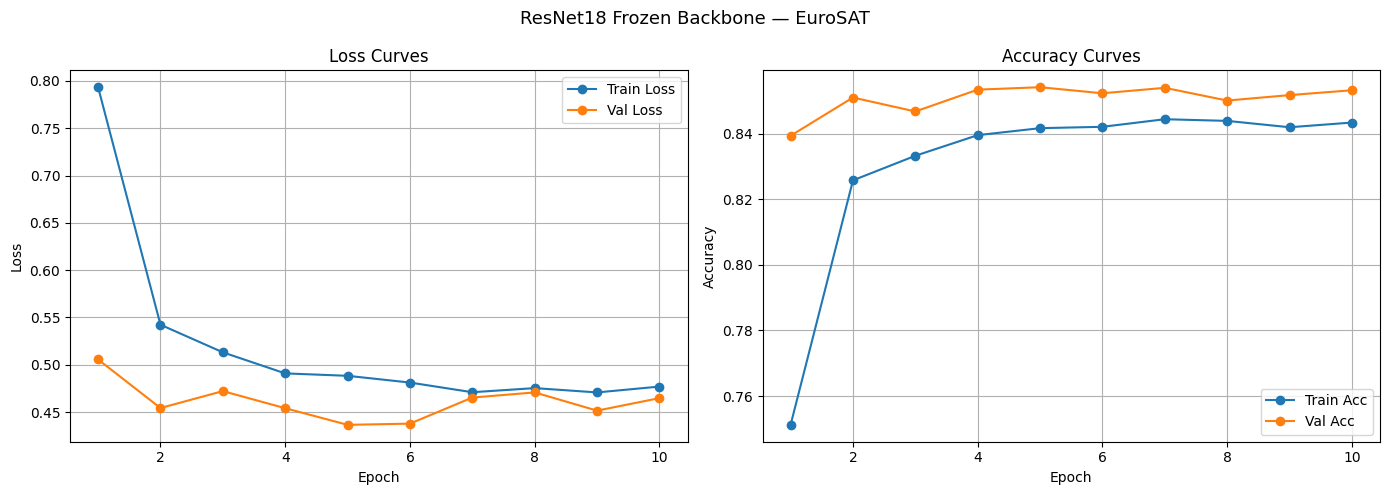

In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, epochs + 1)

# Loss curves
ax1.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='o')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curves
ax2.plot(epochs_range, history['train_acc'], label='Train Acc', marker='o')
ax2.plot(epochs_range, history['val_acc'],   label='Val Acc',   marker='o')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.suptitle('ResNet18 Frozen Backbone — EuroSAT', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Collect all predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to('cuda')
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVeg', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake']

print(classification_report(all_labels, all_preds, target_names=class_names))

Evaluating: 100%|██████████| 169/169 [00:04<00:00, 40.59it/s]

               precision    recall  f1-score   support

   AnnualCrop       0.88      0.90      0.89       591
       Forest       0.88      0.94      0.91       613
HerbaceousVeg       0.80      0.86      0.83       601
      Highway       0.65      0.82      0.73       495
   Industrial       0.94      0.87      0.90       504
      Pasture       0.88      0.85      0.86       422
PermanentCrop       0.86      0.69      0.77       514
  Residential       0.86      0.95      0.90       562
        River       0.89      0.64      0.75       495
      SeaLake       0.95      0.95      0.95       603

     accuracy                           0.85      5400
    macro avg       0.86      0.85      0.85      5400
 weighted avg       0.86      0.85      0.85      5400



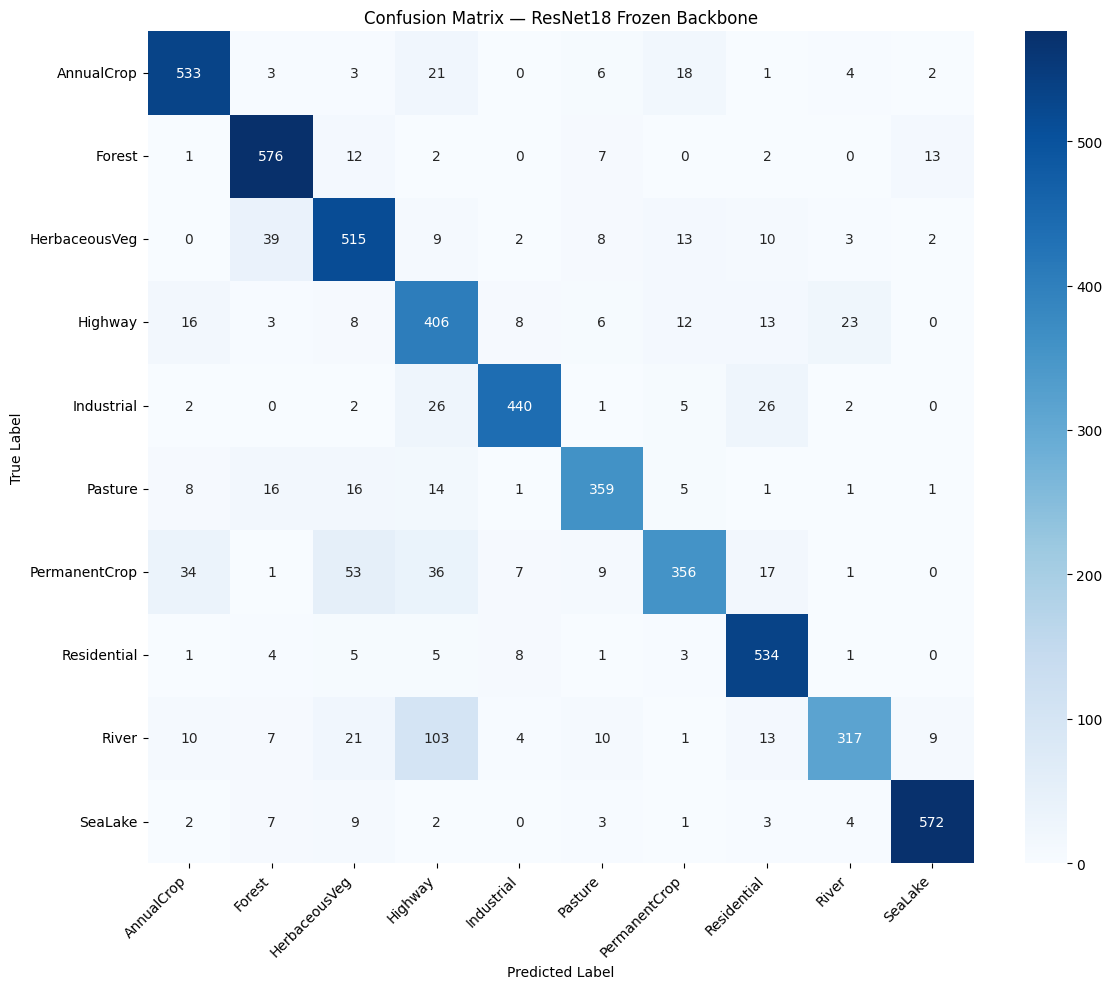

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix — ResNet18 Frozen Backbone')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
# Print final metrics clearly
print("=== Training Summary ===")
print(f"Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Val Loss:   {history['val_loss'][-1]:.4f}")
print(f"Final Train Acc:  {history['train_acc'][-1]:.4f}")
print(f"Final Val Acc:    {history['val_acc'][-1]:.4f}")

# Gap analysis
loss_gap = history['val_loss'][-1] - history['train_loss'][-1]
acc_gap  = history['train_acc'][-1] - history['val_acc'][-1]

print(f"\nLoss gap (val-train): {loss_gap:.4f}")
print(f"Acc gap (train-val):  {acc_gap:.4f}")

# Diagnosis
if acc_gap > 0.1:
    print("\n⚠️  OVERFITTING — model memorizing training data")
elif history['val_acc'][-1] < 0.7:
    print("\n⚠️  UNDERFITTING — model not learning enough")
else:
    print("\n✅ HEALTHY — good generalization")

=== Training Summary ===
Final Train Loss: 0.4770
Final Val Loss:   0.4648
Final Train Acc:  0.8435
Final Val Acc:    0.8533

Loss gap (val-train): -0.0122
Acc gap (train-val):  -0.0099

✅ HEALTHY — good generalization


In [16]:
def quick_train(lr, epochs=3):
    m = models.resnet18(weights='IMAGENET1K_V1')
    m.fc = nn.Linear(512, 10)
    for name, param in m.named_parameters():
        if 'fc' not in name:
            param.requires_grad = False
    m = m.to('cuda')
    opt = optim.Adam(m.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        loss, acc = train_epoch(m, train_loader, criterion, opt)
    
    val_loss, val_acc = val_epoch(m, val_loader, criterion)
    print(f"LR: {lr:.0e} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# Try different learning rates
for lr in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    quick_train(lr)

Validation: 100%|██████████| 169/169 [00:03<00:00, 44.09it/s]


LR: 1e-01 | Val Loss: 9.7072 | Val Acc: 0.8152


Validation: 100%|██████████| 169/169 [00:03<00:00, 53.01it/s]


LR: 1e-02 | Val Loss: 1.3043 | Val Acc: 0.8141


Validation: 100%|██████████| 169/169 [00:03<00:00, 44.37it/s]


LR: 1e-03 | Val Loss: 0.4563 | Val Acc: 0.8546


Validation: 100%|██████████| 169/169 [00:03<00:00, 53.56it/s]


LR: 1e-04 | Val Loss: 0.6476 | Val Acc: 0.8137


Validation: 100%|██████████| 169/169 [00:03<00:00, 55.04it/s]

LR: 1e-05 | Val Loss: 1.8413 | Val Acc: 0.4059


In [17]:
from torch.utils.data import Subset

# Take only 200 samples — too small, model will memorize
small_dataset = Subset(train_dataset, indices=range(200))
small_loader  = DataLoader(small_dataset, batch_size=32, shuffle=True)

# Fresh model
m = models.resnet18(weights='IMAGENET1K_V1')
m.fc = nn.Linear(512, 10)
for name, param in m.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False
m = m.to('cuda')
opt = optim.Adam(m.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Epoch | Train Acc | Val Acc")
print("-" * 35)
for epoch in range(10):
    train_loss, train_acc = train_epoch(m, small_loader, criterion, opt)
    val_loss, val_acc     = val_epoch(m, val_loader, criterion)
    print(f"  {epoch+1:02d}  |   {train_acc:.4f}  |  {val_acc:.4f}")

Epoch | Train Acc | Val Acc
-----------------------------------


Validation: 100%|██████████| 169/169 [00:03<00:00, 51.99it/s]


  01  |   0.1850  |  0.1667


Validation: 100%|██████████| 169/169 [00:04<00:00, 39.85it/s]


  02  |   0.2550  |  0.3056


...

  08  |   0.8350  |  0.5919


Validation: 100%|██████████| 169/169 [00:04<00:00, 38.69it/s]


  09  |   0.9250  |  0.6196


Validation: 100%|██████████| 169/169 [00:03<00:00, 52.14it/s]

  10  |   0.9050  |  0.6320


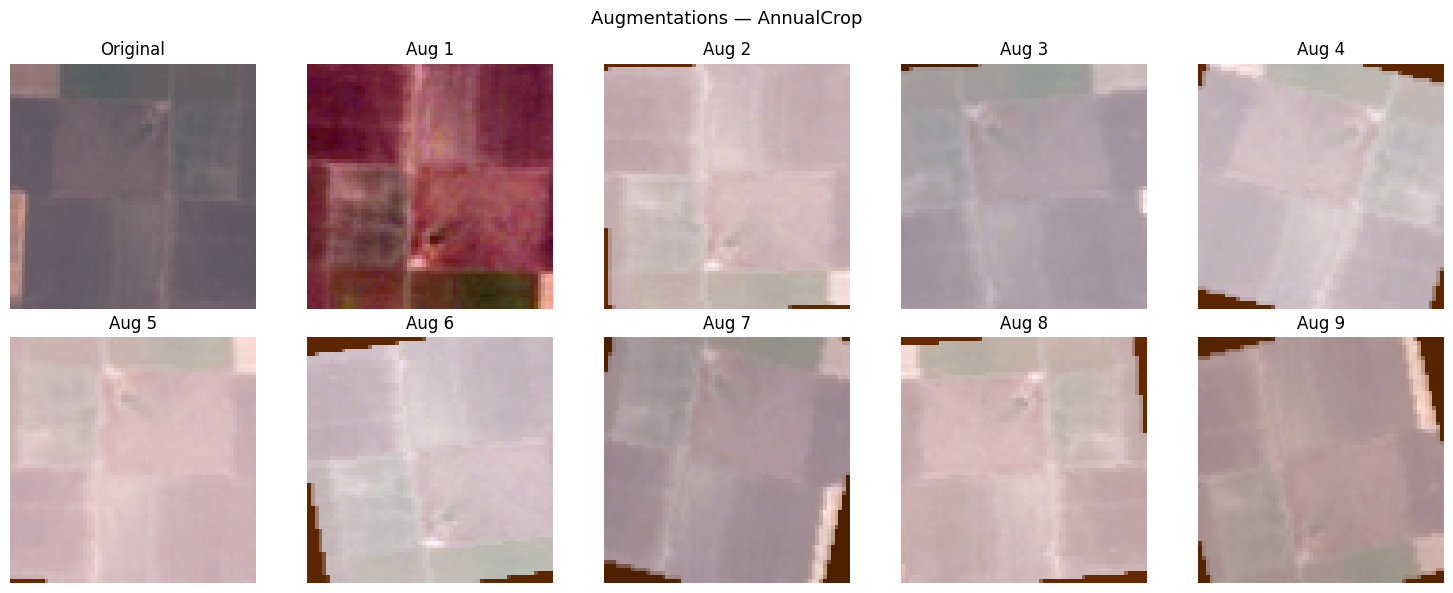

In [18]:
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Define augmentation pipeline
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3444, 0.3803, 0.4078],
                         std=[0.2038, 0.1367, 0.1147])
])

# Load one raw image
raw_dataset = datasets.EuroSAT(root="./data", transform=transforms.ToTensor(), download=False)
raw_image, label = raw_dataset[0]

# Apply augmentation multiple times to same image
aug_dataset = datasets.EuroSAT(root="./data", transform=train_transforms, download=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Original
axes[0].imshow(raw_image.permute(1,2,0))
axes[0].set_title("Original")
axes[0].axis('off')

# 9 augmented versions
for i in range(1, 10):
    aug_image, _ = aug_dataset[0]
    # Denormalize for display
    img = aug_image.permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[i].imshow(img)
    axes[i].set_title(f"Aug {i}")
    axes[i].axis('off')

plt.suptitle(f"Augmentations — {raw_dataset.classes[label]}", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Train gets augmentation, val gets none
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3444, 0.3803, 0.4078],
                         std=[0.2038, 0.1367, 0.1147])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3444, 0.3803, 0.4078],
                         std=[0.2038, 0.1367, 0.1147])
])

# Reload datasets with correct transforms
train_data = datasets.EuroSAT(root="./data", transform=train_transforms, download=False)
val_data   = datasets.EuroSAT(root="./data", transform=val_transforms,   download=False)

# Split
train_dataset, val_dataset = random_split(train_data, [21600, 5400],
                                          generator=torch.Generator().manual_seed(42))

# Important — val_dataset will inherit train_transforms because of how
# random_split works. Fix it:
val_dataset.dataset = val_data

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 21600 | Val: 5400


In [20]:
# Fresh model
model_aug = models.resnet18(weights='IMAGENET1K_V1')
model_aug.fc = nn.Linear(512, 10)
for name, param in model_aug.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False
model_aug = model_aug.to('cuda')

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=0.001)

history_aug = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

epochs = 10

print("Training with Augmentation...")
print(f"{'Epoch':>5} | {'Train Acc':>9} | {'Val Acc':>8}")
print("-" * 32)

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model_aug, train_loader, criterion, optimizer)
    val_loss, val_acc     = val_epoch(model_aug, val_loader, criterion)

    history_aug['train_loss'].append(train_loss)
    history_aug['train_acc'].append(train_acc)
    history_aug['val_loss'].append(val_loss)
    history_aug['val_acc'].append(val_acc)

    print(f"  {epoch+1:02d}   |   {train_acc:.4f}  |  {val_acc:.4f}")

# Compare final results
print("\n=== Baseline vs Augmented ===")
print(f"Baseline  Val Acc: 0.8530")
print(f"Augmented Val Acc: {history_aug['val_acc'][-1]:.4f}")

Training with Augmentation...
Epoch | Train Acc |  Val Acc
--------------------------------


Validation: 100%|██████████| 169/169 [00:03<00:00, 55.65it/s]


  01   |   0.6749  |  0.8069


Validation: 100%|██████████| 169/169 [00:03<00:00, 43.34it/s]


  02   |   0.7448  |  0.8159


...

  08   |   0.7635  |  0.8354


Validation: 100%|██████████| 169/169 [00:03<00:00, 44.74it/s]


  09   |   0.7607  |  0.8335


Validation: 100%|██████████| 169/169 [00:03<00:00, 53.12it/s]

  10   |   0.7549  |  0.8131

=== Baseline vs Augmented ===
Baseline  Val Acc: 0.8530
Augmented Val Acc: 0.8131


In [21]:
# Continue training from where we left off — don't reset
print("Continuing training...")
print(f"{'Epoch':>5} | {'Train Acc':>9} | {'Val Acc':>8}")
print("-" * 32)

for epoch in range(10):  # 10 more epochs = 20 total
    train_loss, train_acc = train_epoch(model_aug, train_loader, criterion, optimizer)
    val_loss, val_acc     = val_epoch(model_aug, val_loader, criterion)

    history_aug['train_loss'].append(train_loss)
    history_aug['train_acc'].append(train_acc)
    history_aug['val_loss'].append(val_loss)
    history_aug['val_acc'].append(val_acc)

    print(f"  {epoch+11:02d}   |   {train_acc:.4f}  |  {val_acc:.4f}")

print(f"\nBaseline  Val Acc: 0.8530")
print(f"Augmented Val Acc: {history_aug['val_acc'][-1]:.4f}")

Continuing training...
Epoch | Train Acc |  Val Acc
--------------------------------


Validation: 100%|██████████| 169/169 [00:03<00:00, 53.75it/s]


  11   |   0.7617  |  0.8359


Validation: 100%|██████████| 169/169 [00:03<00:00, 56.28it/s]


  12   |   0.7620  |  0.8298


...

  18   |   0.7669  |  0.8263


Validation: 100%|██████████| 169/169 [00:03<00:00, 55.44it/s]


  19   |   0.7664  |  0.8354


Validation: 100%|██████████| 169/169 [00:03<00:00, 56.11it/s]

  20   |   0.7643  |  0.8413

Baseline  Val Acc: 0.8530
Augmented Val Acc: 0.8413


In [22]:
# Continue training from where we left off — don't reset
print("Continuing training...")
print(f"{'Epoch':>5} | {'Train Acc':>9} | {'Val Acc':>8}")
print("-" * 32)

for epoch in range(10):  # 10 more epochs = 20 total
    train_loss, train_acc = train_epoch(model_aug, train_loader, criterion, optimizer)
    val_loss, val_acc     = val_epoch(model_aug, val_loader, criterion)

    history_aug['train_loss'].append(train_loss)
    history_aug['train_acc'].append(train_acc)
    history_aug['val_loss'].append(val_loss)
    history_aug['val_acc'].append(val_acc)

    print(f"  {epoch+11:02d}   |   {train_acc:.4f}  |  {val_acc:.4f}")

print(f"\nBaseline  Val Acc: 0.8530")
print(f"Augmented Val Acc: {history_aug['val_acc'][-1]:.4f}")

Continuing training...
Epoch | Train Acc |  Val Acc
--------------------------------


Validation: 100%|██████████| 169/169 [00:03<00:00, 54.34it/s]


  11   |   0.7675  |  0.8339


Validation: 100%|██████████| 169/169 [00:04<00:00, 40.54it/s]


  12   |   0.7636  |  0.8435


...

  18   |   0.7656  |  0.8474


Validation: 100%|██████████| 169/169 [00:03<00:00, 55.78it/s]


  19   |   0.7650  |  0.8378


Validation: 100%|██████████| 169/169 [00:03<00:00, 53.97it/s]

  20   |   0.7665  |  0.8302

Baseline  Val Acc: 0.8530
Augmented Val Acc: 0.8302
